# Phase 6 : Build the ML model

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../data/RTA Dataset.csv")

In [4]:
missing_counts = df.isnull().sum()
print("Missing values before imputation:\n", missing_counts[missing_counts > 0])

categorical_cols = df.select_dtypes(include=["object"]).columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
 Educational_level           741
Vehicle_driver_relation     579
Driving_experience          829
Type_of_vehicle             950
Owner_of_vehicle            482
Service_year_of_vehicle    3928
Defect_of_vehicle          4427
Area_accident_occured       239
Lanes_or_Medians            385
Road_allignment             142
Types_of_Junction           887
Road_surface_type           172
Type_of_collision           155
Vehicle_movement            308
Work_of_casuality          3198
Fitness_of_casuality       2635
dtype: int64
Missing values after imputation:
 Series([], dtype: int64)


C:\Users\hp\AppData\Local\Temp\ipykernel_25608\58781845.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [5]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print(df[categorical_cols].head())

   Time  Day_of_week  Age_band_of_driver  Sex_of_driver  Educational_level  \
0   420            1                   0              1                  0   
1   420            1                   1              1                  4   
2   420            1                   0              1                  4   
3   594            3                   0              1                  4   
4   594            3                   0              1                  4   

   Vehicle_driver_relation  Driving_experience  Type_of_vehicle  \
0                        0                   0                0   
1                        0                   3               11   
2                        0                   0                5   
3                        0                   2               11   
4                        0                   1                0   

   Owner_of_vehicle  Service_year_of_vehicle  ...  Vehicle_movement  \
0                 3                        3  ...        

In [7]:
X = df.drop(column, axis=1)
y = df[column]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:\n", y.value_counts())

X shape: (12316, 31)
y shape: (12316,)
Target distribution:
 Accident_severity
2    10415
1     1743
0      158
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9852, 31)
X_test shape: (2464, 31)
y_train shape: (9852,)
y_test shape: (2464,)


In [9]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8453733766233766


c:\Users\hp\OneDrive\Desktop\Road_Accident_Severity_Analyzer\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7536525974025974


In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8457792207792207


In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.845373
1,Decision Tree,0.753653
2,Random Forest,0.845779


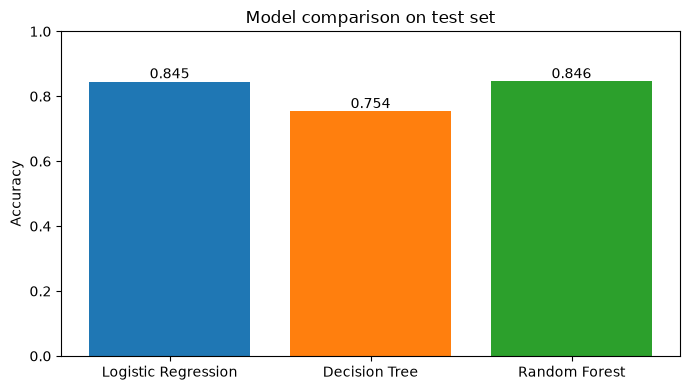

In [15]:
ig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison["Model"], comparison["Accuracy"], color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Model comparison on test set")
for idx, score in enumerate(comparison["Accuracy"]):
    ax.text(idx, score + 0.01, f"{score:.3f}", ha="center")
plt.tight_layout()
plt.show()

In [18]:

import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

# Phase 7: Model Evaluation

In [19]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import matplotlib.pyplot as plt

In [21]:
rf_predictions = rf_model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, rf_predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 84.58 %


In [24]:
precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("Precision:", round(precision, 4))

Precision: 0.7795


c:\Users\hp\OneDrive\Desktop\Road_Accident_Severity_Analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("Recall:", round(recall, 4))

Recall: 0.8458


In [26]:
f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print("F1 Score:", round(f1, 4))

F1 Score: 0.7783


In [27]:
print(classification_report(
    y_test,
    rf_predictions
))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.44      0.01      0.02       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.43      0.34      0.31      2464
weighted avg       0.78      0.85      0.78      2464



c:\Users\hp\OneDrive\Desktop\Road_Accident_Severity_Analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Desktop\Road_Accident_Severity_Analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Desktop\Road_Accident_Severity_Analyzer\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

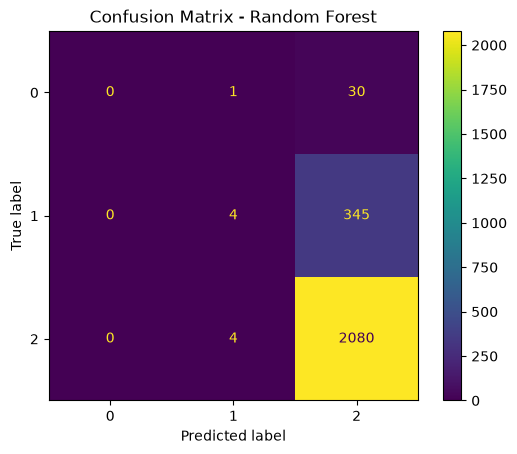

In [28]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

display.plot()

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,Time,0.120198
30,Cause_of_accident,0.067599
1,Day_of_week,0.058443
7,Type_of_vehicle,0.057689
11,Area_accident_occured,0.051854
6,Driving_experience,0.047899
12,Lanes_or_Medians,0.042775
2,Age_band_of_driver,0.041995
22,Vehicle_movement,0.041537
20,Number_of_vehicles_involved,0.040274


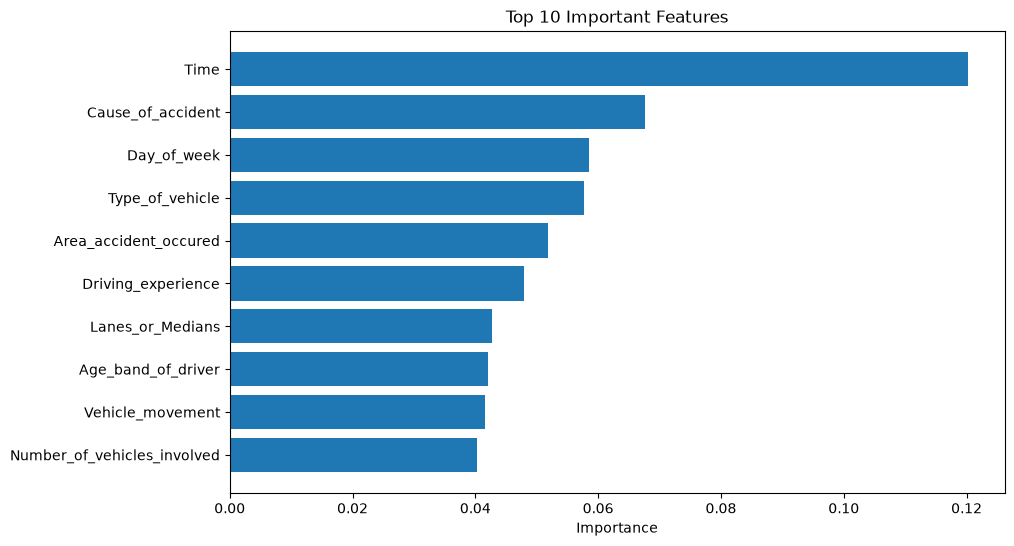

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

Model Evaluation Observations

-Random Forest achieved the best test accuracy (0.8458), slightly outperforming Logistic Regression (0.8454) and clearly outperforming the Decision Tree (0.7537).
-The high recall for the Random Forest model indicates it captures the majority of actual accident severity cases, but the lower weighted precision and F1-score show some false positives remain.
-The confusion matrix suggests most predictions are concentrated in one class, so the model may still struggle with less frequent severity labels.
-Feature importance shows 'Time', 'Cause_of_accident', 'Day_of_week', 'Type_of_vehicle', and 'Area_accident_occured' are the most influential predictors.
-Overall, the Random Forest is the most reliable classifier in this setup, but further work on class imbalance and per-class performance is needed to improve predictions for minority severity categories.